# **Phishing URL Detection** 


Sumber dataset 
Kumpulan URL

### **1. Data Understanding**


#### **1.1 Loading Dataset**

In [108]:
#Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
import joblib
import os
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv')
df.iloc[50:70]

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
50,8030239.txt,https://dev-634536.pantheonsite.io/,34,dev-634536.pantheonsite.io,26,0,io,76.134122,0.826087,0.012927,...,0,0,0,4,0,0,0,0,3,0
51,96527.txt,https://www.senacases.com,24,www.senacases.com,17,0,com,100.000000,1.000000,0.522907,...,1,0,1,42,26,53,139,3,40,1
52,8050920.txt,https://sabadonoappmagazine.com/,32,sabadonoappmagazine.com,23,0,com,64.429742,1.000000,0.522907,...,0,0,0,0,0,0,0,0,0,0
53,626639.txt,https://www.vespatales.com,25,www.vespatales.com,18,0,com,100.000000,1.000000,0.522907,...,0,0,0,180,3,7,260,0,124,1
54,mw27703.txt,http://www.nextraload.com,24,www.nextraload.com,18,0,com,72.108844,1.000000,0.522907,...,0,0,0,0,0,0,0,0,0,0
55,145087.txt,https://www.klerk.ru,19,www.klerk.ru,12,0,ru,100.000000,1.000000,0.018013,...,1,0,0,15,4,8,142,1,91,1
56,28887.txt,https://www.karenmillen.com,26,www.karenmillen.com,19,0,com,100.000000,1.000000,0.522907,...,1,1,1,3,8,50,403,2,417,1
57,8024229.txt,https://topaka.cloud/ob52gtplj/18snwp,36,topaka.cloud,12,0,cloud,32.017440,1.000000,0.000182,...,0,0,0,0,2,0,2,0,2,0
58,404766.txt,https://www.mlpack.org,21,www.mlpack.org,14,0,org,100.000000,1.000000,0.079963,...,1,0,1,1,1,3,1,0,10,1
59,8017962.txt,https://metafb-tvz6efk.web.app/,30,metafb-tvz6efk.web.app,22,0,app,51.953371,0.444444,0.001502,...,0,0,0,0,0,2,0,0,1,0


In [109]:
#Cek kolom
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

#### **1.2 Dataset Information**

In [110]:
#Informasi mengenai dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [111]:
#Menghitung jumlah nilai unik setiap kolom
df.nunique()

FILENAME                      235795
URL                           235370
URLLength                        482
Domain                        220086
DomainLength                     101
IsDomainIP                         2
TLD                              695
URLSimilarityIndex             36360
CharContinuationRate             898
TLDLegitimateProb                465
URLCharProb                   227421
TLDLength                         12
NoOfSubDomain                     10
HasObfuscation                     2
NoOfObfuscatedChar                20
ObfuscationRatio                 146
NoOfLettersInURL                 421
LetterRatioInURL                 709
NoOfDegitsInURL                  182
DegitRatioInURL                  575
NoOfEqualsInURL                   25
NoOfQMarkInURL                     5
NoOfAmpersandInURL                31
NoOfOtherSpecialCharsInURL        74
SpacialCharRatioInURL            240
IsHTTPS                            2
LineOfCode                     10738
L

In [112]:
#Hitung jumlah masing-masing kelas
df["label"].value_counts(normalize=True)*100
#1 = Legitimate URL
#0 = Phishing URL

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64

#### **1.3 Missing Values and Duplicate Check**

In [113]:
#Cek missing value
df.isnull().sum().sum()

np.int64(0)

In [114]:
#Cek duplikat
df.duplicated().sum()

np.int64(0)

In [115]:
#Memilih fitur
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

# **2. Explanatory Data Analysis (EDA)**

## **2.1 Distribusi Class**

In [116]:
#Hitung jumlah data masing-masing label
class_counts = df["label"].value_counts().sort_index()
print(class_counts)


label
0    100945
1    134850
Name: count, dtype: int64


In [117]:
#Cek kolom URL yan duplikat
df["URL"].duplicated().sum()

np.int64(425)

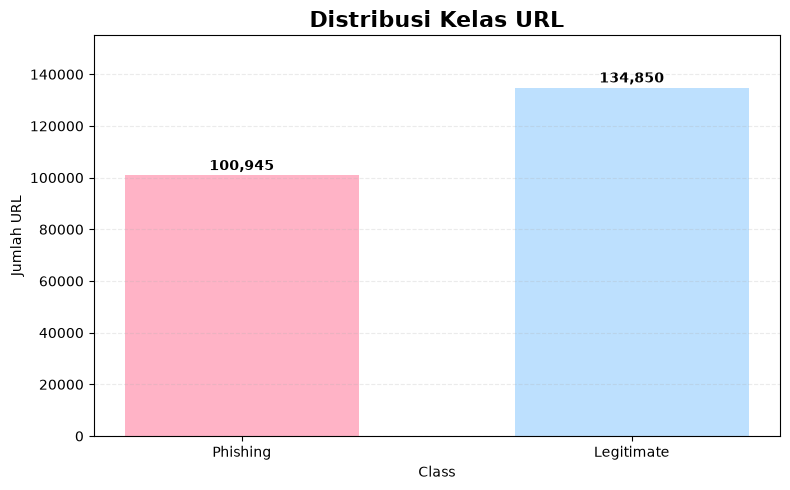

In [118]:
labels = ["Phishing", "Legitimate"]
colors = ["#FFB3C6", "#BDE0FE"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    class_counts.values,
    color=colors,
    width=0.6
)

plt.title("Distribusi Kelas URL", fontsize=16, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Jumlah URL")

plt.grid(axis="y", linestyle="--", alpha=0.25)

# Tampilkan jumlah di atas bar
for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f"{count:,}",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

In [119]:
# Korelasi fitur terhadap label
corr_data = df[url_features + ["label"]].corr()

target_corr = (
    corr_data["label"]
    .drop("label")
    .sort_values()
)

target_corr

SpacialCharRatioInURL        -0.533537
DegitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233445
NoOfDegitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
ObfuscationRatio             -0.041915
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
IsHTTPS                       0.609132
Name: label, dtype: float64

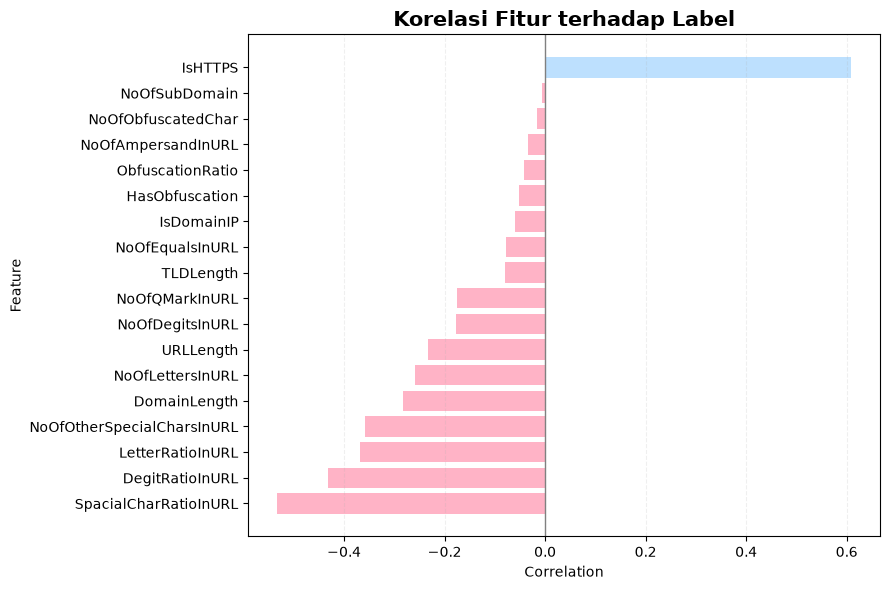

In [120]:
colors = [
    "#FFB3C6" if x < 0 else "#BDE0FE"
    for x in target_corr.values
]

plt.figure(figsize=(9, 6))

plt.barh(
    target_corr.index,
    target_corr.values,
    color=colors
)

plt.axvline(0, color="gray", linewidth=1)

plt.title(
    "Korelasi Fitur terhadap Label",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.2)

plt.tight_layout()
plt.show()

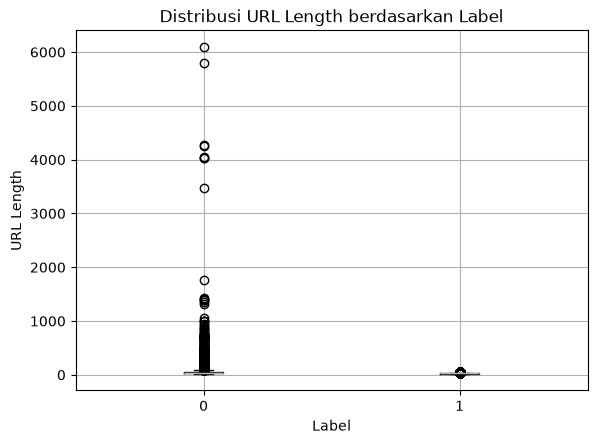

In [121]:
df.boxplot(column="URLLength", by="label")
plt.title("Distribusi URL Length berdasarkan Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("URL Length")
plt.show()



#### **2.2 URL and Domain Characteristics**

In [122]:
df["DomainLength"].describe()

count    235795.000000
mean         21.470396
std           9.150793
min           4.000000
25%          16.000000
50%          20.000000
75%          24.000000
max         110.000000
Name: DomainLength, dtype: float64

In [123]:
df["URLLength"].describe()

count    235795.000000
mean         34.573095
std          41.314153
min          13.000000
25%          23.000000
50%          27.000000
75%          34.000000
max        6097.000000
Name: URLLength, dtype: float64

In [124]:
df[url_features]. describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.0,23.000,27.000,34.000,6097.000
DomainLength,235795.0,21.470396,9.150793,4.0,16.000,20.000,24.000,110.000
IsDomainIP,235795.0,0.002706,0.051946,0.0,0.000,0.000,0.000,1.000
TLDLength,235795.0,2.764456,0.599739,2.0,2.000,3.000,3.000,13.000
NoOfSubDomain,235795.0,1.164758,0.600969,0.0,1.000,1.000,1.000,10.000
HasObfuscation,235795.0,0.002057,0.045306,0.0,0.000,0.000,0.000,1.000
NoOfObfuscatedChar,235795.0,0.024861,1.876249,0.0,0.000,0.000,0.000,447.000
ObfuscationRatio,235795.0,0.000138,0.003817,0.0,0.000,0.000,0.000,0.348
NoOfLettersInURL,235795.0,19.428919,29.090330,0.0,10.000,14.000,20.000,5191.000
LetterRatioInURL,235795.0,0.515946,0.123315,0.0,0.435,0.519,0.594,0.926


In [125]:
corr = df[url_features+ ["label"]].corr()

In [126]:
target_corr = corr["label"].drop("label").sort_values()
print(target_corr)

SpacialCharRatioInURL        -0.533537
DegitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233445
NoOfDegitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
ObfuscationRatio             -0.041915
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
IsHTTPS                       0.609132
Name: label, dtype: float64


#### **2.3 Duplicate URL Handling**

In [127]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate URLs:", df["URL"].duplicated().sum())

Duplicate rows: 0
Duplicate URLs: 425


In [128]:
duplicate_urls = df[df["URL"].duplicated(keep=False)]

duplicate_urls[
    ["URL", "label"]
].sort_values("URL").head(20)


,URL,label
219489,http://2f3a.reicrut-chat.workers.dev/,0
57609,http://2f3a.reicrut-chat.workers.dev/,0
227564,http://34.149.138.117/,0
27166,http://34.149.138.117/,0
147448,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
189978,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
57315,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
31955,http://595221.selcdn.ru/qwerty-ohdhdjejnnad-na...,0
197956,http://91.239.125.28/postchs/sms.php,0
126246,http://91.239.125.28/postchs/sms.php,0


In [129]:
df_clean = df.drop_duplicates(subset="URL").copy()

print("Sebelum :", len(df))
print("Sesudah :", len(df_clean))
print("Duplicate URL:", df_clean["URL"].duplicated().sum())

Sebelum : 235795
Sesudah : 235370
Duplicate URL: 0


In [130]:
for col in url_features:
    if df[col].nunique() == 2:
        print(f"\n{col}")
        print(df[col].value_counts(normalize=True).round(3))


IsDomainIP
IsDomainIP
0    0.997
1    0.003
Name: proportion, dtype: float64

HasObfuscation
HasObfuscation
0    0.998
1    0.002
Name: proportion, dtype: float64

IsHTTPS
IsHTTPS
1    0.783
0    0.217
Name: proportion, dtype: float64


In [131]:
#Memilih fitur
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

# **3. Initial Model Experiment**

#### **3.1 Feature Selection**

In [132]:
#Memisahkan data fitur dan target (label)
x = df[url_features].copy()
y = df["label"].copy()
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (235795, 18)
y shape: (235795,)


#### **3.2 Train-Test Split**

In [133]:
X = df_clean[url_features].copy()
y = df_clean["label"].copy()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", x_train.shape)
print("Test:", x_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train: (188296, 18)
Test: (47074, 18)

Train distribution:
label
1    0.572928
0    0.427072
Name: proportion, dtype: float64

Test distribution:
label
1    0.572928
0    0.427072
Name: proportion, dtype: float64


In [134]:
StandardScaler().fit_transform(x)

array([[-0.08648617,  0.27643609, -0.05208724, ..., -0.37991824,
        -0.96655038,  0.52702143],
       [-0.28012483, -0.59780692, -0.05208724, ..., -0.09643906,
         0.73135229,  0.52702143],
       [-0.13489583,  0.05787534, -0.05208724, ..., -0.09643906,
         0.17567505,  0.52702143],
       ...,
       [-0.110691  ,  0.16715571, -0.05208724, ..., -0.37991824,
        -0.93567942,  0.52702143],
       [ 0.4944298 ,  2.78988473, -0.05208724, ...,  0.75399846,
         0.85483612,  0.52702143],
       [-0.03807651,  0.49499684, -0.05208724, ..., -0.37991824,
        -1.02829229,  0.52702143]], shape=(235795, 18))

#### **3.3 Logistic Regression**

In [135]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
baseline_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['URLLength','DomainLength','IsDomainIP',...,'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL','IsHTTPS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [136]:
#Prediksi dataset
y_pred = baseline_model.predict(x_test)
y_prob = baseline_model.predict_proba(x_test)[:, 1]

In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9959425585248757
Precision: 0.9932947721327783
Recall   : 0.9996662958843159
F1 Score : 0.9964703490843235
ROC-AUC  : 0.9981262996009921

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20104
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



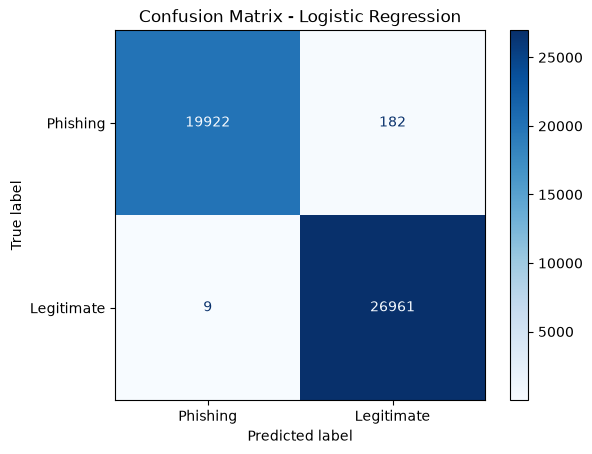

In [184]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [139]:
print("Duplicate URLs:", df_clean["URL"].duplicated().sum())

Duplicate URLs: 0


In [140]:
train_urls = set(df.loc[x_train.index, "URL"])
test_urls = set(df.loc[x_test.index, "URL"])

overlap_urls = train_urls.intersection(test_urls)

print("Duplicate URL dataset :", df_clean["URL"].duplicated().sum())
print("URL overlap train-test:", len(overlap_urls))

Duplicate URL dataset : 0
URL overlap train-test: 0


#### **3.4 Random Forest**

In [141]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [142]:
rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, rf_pred))
print("Precision: ", precision_score(y_test, rf_pred))
print("Recall: ", recall_score(y_test, rf_pred))
print("F1 Score: ", f1_score(y_test, rf_pred))
print("ROC-AUC: ", roc_auc_score(y_test, rf_prob))

print("\nClassification report: ")
print(classification_report(y_test, rf_pred))

Accuracy:  0.9974295789607851
Precision:  0.9961929403067825
Recall:  0.9993325917686318
F1 Score:  0.9977602961591856
ROC-AUC:  0.9982388778942748

Classification report: 
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



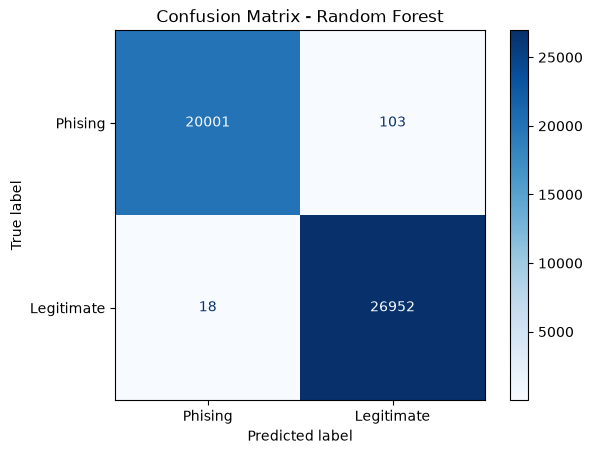

In [143]:
rf_cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Phising", "Legitimate"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

#### **3.5 HistGradientBoosting**

In [144]:
#HistGradientBoostin
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    random_state=42
)

hgb_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [145]:
hgb_pred = hgb_model.predict(x_test)
hgb_prob = hgb_model.predict_proba(x_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, hgb_pred))
print("Precision: ", precision_score(y_test,hgb_pred))
print("Recall: ", recall_score(y_test, hgb_pred))
print("f1 Score: ", f1_score(y_test, hgb_pred))
print("ROC_AUC :", roc_auc_score(y_test, hgb_prob))

print("\nClassification report: ")
print(classification_report(y_test, hgb_pred))

Accuracy:  0.9974720652589539
Precision:  0.9959732535372566
Recall:  0.9996292176492398
f1 Score:  0.9977978867114491
ROC_AUC : 0.9986154532581853

Classification report: 
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



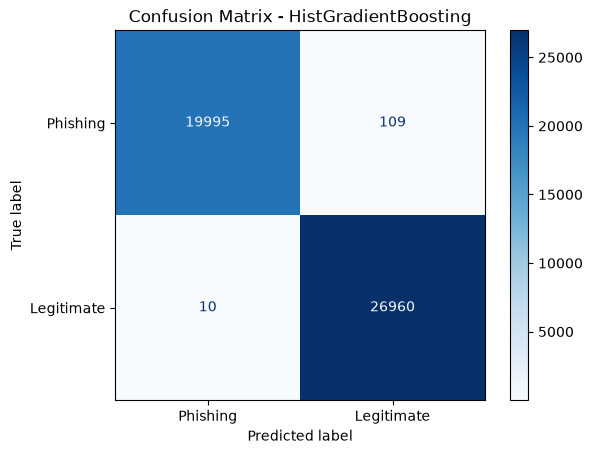

In [146]:
hgb_cm = confusion_matrix(y_test, hgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=hgb_cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - HistGradientBoosting")
plt.show()

#### **3.6 Model Comparison**

In [147]:
#Phising score
loreg_phishing_recall = recall_score(y_test, y_pred, pos_label=0)
rf_phishing_recall = recall_score(y_test, rf_pred, pos_label=0)
hgb_phishing_recall = recall_score(y_test, hgb_pred, pos_label=0)


In [148]:
comparison = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Accuracy" : [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, hgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, hgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, hgb_prob)
    ],

    "Phishing Recall": [
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, rf_pred, pos_label=0),
        recall_score(y_test, hgb_pred, pos_label=0)
    ]
})
comparison.round(4)

,Model,Accuracy,F1 Score,ROC-AUC,Phishing Recall
0,Logistic Regression,0.9959,0.9965,0.9981,0.9909
1,Random Forest,0.9974,0.9978,0.9982,0.9949
2,HistGradientBoosting,0.9975,0.9978,0.9986,0.9946


Analisis Perbandingan Model

Berdasarkan hasil evaluasi, ketiga model menunjukkan performa yang sangat tinggi. Logistic Regression memperoleh accuracy 99,59%, sedangkan Random Forest dan HistGradientBoosting masing-masing mencapai sekitar 99,74% dan 99,75%.

HistGradientBoosting menghasilkan accuracy dan ROC-AUC tertinggi, yaitu sekitar 99,75% dan 99,86%. Namun, dalam kasus phishing detection, accuracy bukan satu-satunya metrik yang perlu diperhatikan. Kesalahan ketika URL phishing diprediksi sebagai legitimate memiliki risiko yang lebih besar bagi pengguna.

Oleh karena itu, Phishing Recall digunakan untuk melihat kemampuan model dalam mendeteksi URL phishing. Random Forest memperoleh Phishing Recall tertinggi sebesar 99,49%, sedikit lebih tinggi dibandingkan HistGradientBoosting sebesar 99,46% dan Logistic Regression sebesar 99,09%.

Berdasarkan pertimbangan tersebut, Random Forest dipilih pada tahap ini untuk dilakukan hyperparameter tuning karena memiliki kemampuan terbaik dalam mendeteksi kelas phishing.

#### **3.7 Random Forest Hyperparameter Tuning**

In [149]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
phising_recall_scorer = make_scorer(
    recall_score,
    pos_label=0
)
rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ), 
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring=phising_recall_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [150]:
rf_tuning.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(r..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can b

In [151]:
print("Best Parameters:")
print(rf_tuning.best_params_)

print("\nBest CV Phishing Recall:")
print(rf_tuning.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best CV Phishing Recall:
0.9947025574250867


In [152]:
#Evaluasi random forest
best_rf = rf_tuning.best_estimator_

tuned_pred = best_rf.predict(x_test)
tuned_prob = best_rf.predict_proba(x_test)[:, 1]

In [153]:
print("Accracy: ", accuracy_score(y_test, tuned_pred))
print("F1 Score: ", f1_score(y_test, tuned_pred))
print("ROC-AUC: ", roc_auc_score(y_test, tuned_prob))
print(
    "Phising Recall: ", 
    recall_score(y_test, tuned_pred, pos_label=0)
)

Accracy:  0.9972596337681098
F1 Score:  0.9976123049586318
ROC-AUC:  0.9984110120882719
Phising Recall:  0.9946279347393554


Analisis Hyperparameter Tuning

Hyperparameter tuning dilakukan pada Random Forest menggunakan RandomizedSearchCV dengan 3-fold cross-validation. Proses tuning difokuskan pada Phishing Recall karena tujuan utama sistem adalah meminimalkan URL phishing yang salah diklasifikasikan sebagai legitimate.

Parameter yang diuji meliputi jumlah estimator, kedalaman maksimum tree, minimum sample untuk melakukan split, minimum sample pada leaf, dan jumlah fitur yang dipertimbangkan pada setiap split.

Hasil tuning memperoleh kombinasi parameter terbaik yaitu `n_estimators=100`, `max_depth=20`, `min_samples_split=5`, `min_samples_leaf=1`, dan `max_features='log2'`, dengan rata-rata Phishing Recall pada cross-validation sekitar 99,46%.

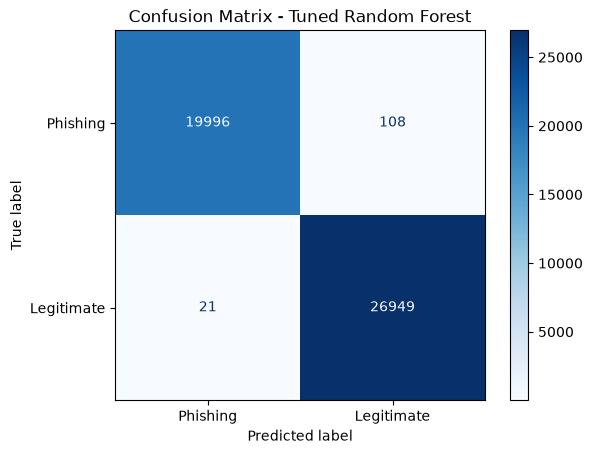

In [154]:
tuned_cm = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm, display_labels=["Phishing", "Legitimate"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

#### **3.8 Before vs After Tuning**

In [155]:
#Before vs After Tuning
before_after = pd.DataFrame({
    "Model": [
        "Random Forest Before Tuning",
        "Random Forest After Tuning"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_pred)
    ],

    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, tuned_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, tuned_prob)
    ],

    "Phishing Recall": [
        recall_score(y_test, rf_pred, pos_label=0),
        recall_score(y_test, tuned_pred, pos_label=0)
    ]
})

before_after.round(4)

,Model,Accuracy,F1 Score,ROC-AUC,Phishing Recall
0,Random Forest Before Tuning,0.9974,0.9978,0.9982,0.9949
1,Random Forest After Tuning,0.9973,0.9976,0.9984,0.9946


 Analisis Before vs After Tuning

Hasil evaluasi menunjukkan bahwa hyperparameter tuning tidak memberikan peningkatan performa pada sebagian besar metrik. Random Forest sebelum tuning memperoleh accuracy 99,74%, F1-Score 99,78%, dan Phishing Recall 99,49%. Setelah tuning, nilainya sedikit menurun menjadi accuracy 99,73%, F1-Score 99,76%, dan Phishing Recall 99,46%.

ROC-AUC mengalami sedikit peningkatan dari 99,82% menjadi 99,84%, tetapi peningkatan tersebut tidak diikuti oleh peningkatan pada metrik lainnya, khususnya Phishing Recall yang menjadi salah satu fokus utama pada sistem ini.

Dengan demikian, Random Forest sebelum tuning tetap memberikan hasil yang lebih sesuai untuk tujuan deteksi phishing. Hasil ini juga menunjukkan bahwa hyperparameter tuning tidak selalu menghasilkan performa yang lebih baik pada test set.

In [182]:
test_url = "https://www.southbankmosaics.com"

extract_features(test_url)

{'URLLength': 32,
 'DomainLength': 24,
 'IsDomainIP': 0,
 'TLDLength': 3,
 'NoOfSubDomain': 1,
 'NoOfLettersInURL': 27,
 'LetterRatioInURL': 0.84375,
 'NoOfDegitsInURL': 0,
 'DegitRatioInURL': 0.0,
 'NoOfEqualsInURL': 0,
 'NoOfQMarkInURL': 0,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 5,
 'SpacialCharRatioInURL': 0.15625,
 'IsHTTPS': 1}

## **4. URL Feature Engineering for Deployment**

Pada tahap modeling awal, model menggunakan fitur yang telah tersedia pada dataset PhiUSIIL. Namun, tidak seluruh fitur tersebut dapat digunakan secara langsung ketika sistem menerima URL baru dari pengguna.

Pada implementasi aplikasi, pengguna hanya memasukkan sebuah URL. Oleh karena itu, sistem harus mampu menghasilkan sendiri fitur-fitur yang dibutuhkan model hanya dari URL tersebut. Beberapa fitur pada dataset merupakan fitur *precomputed* dan sebagian lainnya membutuhkan informasi dari konten halaman website, sehingga tidak dapat direproduksi secara konsisten hanya dari URL mentah.

Jika model dilatih menggunakan fitur dari dataset tetapi pada saat prediksi fitur dihitung dengan metode yang berbeda, dapat terjadi **training-serving skew**, yaitu perbedaan antara cara fitur diperoleh saat training dan saat sistem digunakan.

Untuk mengatasi masalah tersebut, dilakukan feature engineering dengan menghitung ulang fitur-fitur leksikal dan struktural secara langsung dari kolom URL. Feature extractor yang sama kemudian digunakan pada proses training dan inference sehingga representasi fitur yang diterima model tetap konsisten.

#### **4.1 Feature Extraction Problem**

In [158]:
from urllib.parse import urlparse, urlunparse
import ipaddress
import pandas as pd

def normalize_url(url):
    url = str(url).strip()

    if "://" not in url:
        url = "http://" + url

    parsed = urlparse(url)

    # lowercase scheme dan domain
    scheme = parsed.scheme.lower()
    netloc = parsed.netloc.lower()

    path = parsed.path

    # "/" tunggal di akhir domain tidak membawa informasi
    if path == "/":
        path = ""

    normalized = urlunparse((
        scheme,
        netloc,
        path,
        parsed.params,
        parsed.query,
        parsed.fragment
    ))

    return normalized

def extract_features(url):
    raw_url = normalize_url(url)

    # khusus untuk parsing
    #parse_url = raw_url
    #if "://" not in parse_url:
        #parse_url = "http://" + parse_url

    parsed = urlparse(raw_url)

    domain = parsed.hostname or ""

    # 1. URL Length
    url_length = len(raw_url)

    # 2. Domain Length
    domain_length = len(domain)

    # 3. Is Domain IP
    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    # 4. TLD Length
    domain_parts = domain.split(".")
    tld = domain_parts[-1] if len(domain_parts) > 1 else ""
    tld_length = len(tld)

    # 5. Number of Subdomains
    no_of_subdomain = max(len(domain_parts) - 2, 0)

    # 6. Number of Letters
    no_of_letters = sum(
        c.isalpha()
        for c in raw_url
    )

    # 7. Letter Ratio
    letter_ratio = (
        no_of_letters / url_length
        if url_length > 0 else 0
    )

    # 8. Number of Digits
    no_of_digits = sum(
        c.isdigit()
        for c in raw_url
    )

    # 9. Digit Ratio
    digit_ratio = (
        no_of_digits / url_length
        if url_length > 0 else 0
    )
    # 10. jumlah =
    no_of_equals = raw_url.count("=")

    # 11. jumlah ?
    no_of_qmark = raw_url.count("?")

    # 12. jumlah &
    no_of_ampersand = raw_url.count("&")

    # 13. jumlah karakter selain huruf/angka
    no_of_special_chars = sum(
        1 for c in raw_url
        if not c.isalnum()
    )

    # 14. rasio special character
    special_char_ratio = (
        no_of_special_chars / url_length
        if url_length > 0 else 0
    )

    # 15. HTTPS
    is_https = (
        1
        if parsed.scheme.lower() == "https"
        else 0
    )
    return {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": is_domain_ip,
        "TLDLength": tld_length,
        "NoOfSubDomain": no_of_subdomain,
        "NoOfLettersInURL": no_of_letters,
        "LetterRatioInURL": letter_ratio,
        "NoOfDegitsInURL": no_of_digits,
        "DegitRatioInURL": digit_ratio,
        "NoOfEqualsInURL": no_of_equals,
        "NoOfQMarkInURL": no_of_qmark,
        "NoOfAmpersandInURL": no_of_ampersand,
        "NoOfOtherSpecialCharsInURL": no_of_special_chars,
        "SpacialCharRatioInURL": special_char_ratio,
        "IsHTTPS": is_https
    }

In [159]:
test_url = "https://www.southbankmosaics.com"

extract_features(test_url)

{'URLLength': 32,
 'DomainLength': 24,
 'IsDomainIP': 0,
 'TLDLength': 3,
 'NoOfSubDomain': 1,
 'NoOfLettersInURL': 27,
 'LetterRatioInURL': 0.84375,
 'NoOfDegitsInURL': 0,
 'DegitRatioInURL': 0.0,
 'NoOfEqualsInURL': 0,
 'NoOfQMarkInURL': 0,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 5,
 'SpacialCharRatioInURL': 0.15625,
 'IsHTTPS': 1}

In [160]:
x_final = (
    df_clean["URL"]
    .apply(extract_features)
    .apply(pd.Series)
)

y_final = df_clean["label"].copy()

print("Shape x_final:", x_final.shape)
print("Shape y_final:", y_final.shape)

x_final

Shape x_final: (235370, 15)
Shape y_final: (235370,)


,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,32.0,24.0,0.0,3.0,1.0,27.0,0.843750,0.0,0.000000,0.0,0.0,0.0,5.0,0.156250,1.0
1,24.0,16.0,0.0,2.0,1.0,18.0,0.750000,0.0,0.000000,0.0,0.0,0.0,6.0,0.250000,1.0
2,30.0,22.0,0.0,2.0,2.0,24.0,0.800000,0.0,0.000000,0.0,0.0,0.0,6.0,0.200000,1.0
3,27.0,19.0,0.0,3.0,1.0,22.0,0.814815,0.0,0.000000,0.0,0.0,0.0,5.0,0.185185,1.0
4,34.0,26.0,0.0,3.0,1.0,29.0,0.852941,0.0,0.000000,0.0,0.0,0.0,5.0,0.147059,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,30.0,22.0,0.0,3.0,1.0,25.0,0.833333,0.0,0.000000,0.0,0.0,0.0,5.0,0.166667,1.0
235791,29.0,21.0,0.0,2.0,2.0,23.0,0.793103,0.0,0.000000,0.0,0.0,0.0,6.0,0.206897,1.0
235792,31.0,23.0,0.0,2.0,1.0,26.0,0.838710,0.0,0.000000,0.0,0.0,0.0,5.0,0.161290,1.0
235793,55.0,47.0,0.0,3.0,2.0,44.0,0.800000,3.0,0.054545,0.0,0.0,0.0,8.0,0.145455,1.0


In [161]:
x_final.isnull().sum()

URLLength                     0
DomainLength                  0
IsDomainIP                    0
TLDLength                     0
NoOfSubDomain                 0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
dtype: int64

#### **4.2 Final Train-Test Split**

In [162]:
x_train_final, x_test_final, y_train_final, y_test_final = train_test_split(
    x_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)
print("Train:", x_train_final.shape)
print("Test :", x_test_final.shape)

Train: (188296, 15)
Test : (47074, 15)


#### **4.3 Domain-Based Split Preparation**

Pada tahap final, pembagian data dilakukan menggunakan GroupShuffleSplit berdasarkan domain URL. 

In [163]:
def get_domain(url):
    url = str(url).strip()

    if "://" not in url:
        url = "http://" + url

    parsed = urlparse(url)

    return parsed.hostname or ""

mengambil nama domain dari setiap URL.

In [164]:
groups = df_clean["URL"].apply(get_domain)

print("Jumlah URL   :", len(df_clean))
print("Jumlah domain:", groups.nunique())

Jumlah URL   : 235370
Jumlah domain: 220077


semua URL dikelompokkan berdasarkan domainnya supaya ketika kita melakukan domain-based split, domain yang ada di training tidak muncul lagi di testing.

#### **4.4 Domain-Based Train-Test Split**

In [165]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        x_final,
        y_final,
        groups=groups
    )
)

x_train_group = x_final.iloc[train_idx]
x_test_group = x_final.iloc[test_idx]

y_train_group = y_final.iloc[train_idx]
y_test_group = y_final.iloc[test_idx]

print("Train:", x_train_group.shape)
print("Test :", x_test_group.shape)

Train: (187856, 15)
Test : (47514, 15)


Berbeda dengan random train-test split, metode ini menjaga agar URL dengan domain yang sama tidak tersebar pada data training dan testing.

Pendekatan ini digunakan untuk membuat evaluasi lebih realistis, karena pada penggunaan sebenarnya sistem dapat menerima URL dari domain yang belum pernah dilihat oleh model selama proses training.

#### **4.5 Domain Overlap Check**

In [166]:
train_domains = set(groups.iloc[train_idx])
test_domains = set(groups.iloc[test_idx])

print(
    "Domain overlap:",
    len(train_domains.intersection(test_domains))
)

Domain overlap: 0


Hasil pemeriksaan menunjukkan `Domain overlap = 0`, yang berarti tidak terdapat domain yang sama antara data training dan testing. Dengan demikian, performa pada tahap ini lebih menggambarkan kemampuan model dalam melakukan generalisasi terhadap domain yang belum pernah dilihat sebelumnya.

## **5. Final Model Evaluation**

#### **5.1 Random Forest Domain Based**

In [167]:
final_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    x_train_group,
    y_train_group
)

print("Training selesai.")

Training selesai.


In [168]:
final_pred = final_rf.predict(x_test_group)

final_prob = final_rf.predict_proba(x_test_group)[:, 1]

In [193]:
accuracy = accuracy_score(
    y_test_group,
    final_pred
)

f1 = f1_score(
    y_test_group,
    final_pred
)

roc_auc = roc_auc_score(
    y_test_group,
    final_prob
)

phishing_recall = recall_score(
    y_test_group,
    final_pred,
    pos_label=0
)

print("Accuracy       :", accuracy)
print("F1 Score       :", f1)
print("ROC-AUC        :", roc_auc)
print("Phishing Recall:", phishing_recall)

Accuracy       : 0.9667676895230879
F1 Score       : 0.9712391395420849
ROC-AUC        : 0.9870991236411745
Phishing Recall: 0.9405621706031622


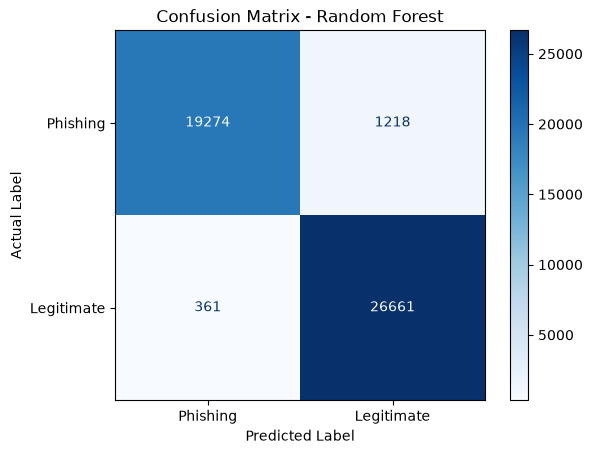

In [192]:
cm = confusion_matrix(
    y_test_group,
    final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Analisis Confusion Matrix - Random Forest

Confusion matrix Random Forest menunjukkan Jumlah URL phishing yang salah diklasifikasikan sebagai legitimate yaitu sebanyak 1218 URL.

Random Forest menghasilkan Phishing Recall sekitar 94,05%. Hal ini menunjukkan bahwa Random Forest memiliki kemampuan yang baik dalam mengenali URL phishing, yang merupakan kelas penting dalam sistem ini.

Meskipun demikian, masih terdapat beberapa kesalahan klasifikasi baik pada URL phishing maupun legitimate, sehingga model belum dapat mendeteksi seluruh URL secara sempurna.

#### **5.2 Logistic Regression Domain Bases**

In [171]:
final_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_lr.fit(
    x_train_group,
    y_train_group
)

lr_pred_final = final_lr.predict(x_test_group)
lr_prob_final = final_lr.predict_proba(x_test_group)[:, 1]

print("Logistic Regression selesai.")

Logistic Regression selesai.


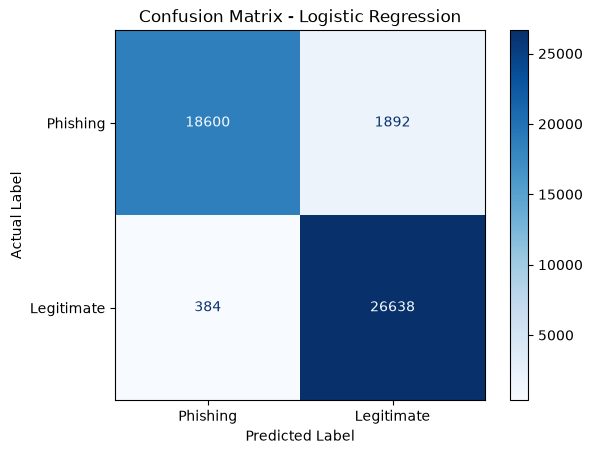

In [186]:
cm_lr = confusion_matrix(
    y_test_group,
    lr_pred_final
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Analisis Confusion Matrix - Logistic Regression

Berdasarkan confusion matrix, Logistic Regression memiliki sekitar 1892 jumlah URL phishing yang salah diprediksi sebagai legitimate.

Kesalahan tersebut perlu diperhatikan karena pada sistem deteksi phishing, URL phishing yang lolos sebagai legitimate memiliki risiko yang lebih tinggi dibandingkan URL legitimate yang salah ditandai sebagai phishing.

Hasil ini sejalan dengan nilai Phishing Recall Logistic Regression yang lebih rendah dibandingkan Random Forest dan HistGradientBoosting, sehingga Logistic Regression masih kurang optimal dalam mendeteksi seluruh URL phishing.

#### **5.3 Hist Gradient Boosting Classifier**

In [172]:
final_hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    random_state=42
)

final_hgb.fit(
    x_train_group,
    y_train_group
)

hgb_pred_final = final_hgb.predict(x_test_group)
hgb_prob_final = final_hgb.predict_proba(x_test_group)[:, 1]

print("HistGradientBoosting selesai.")

HistGradientBoosting selesai.


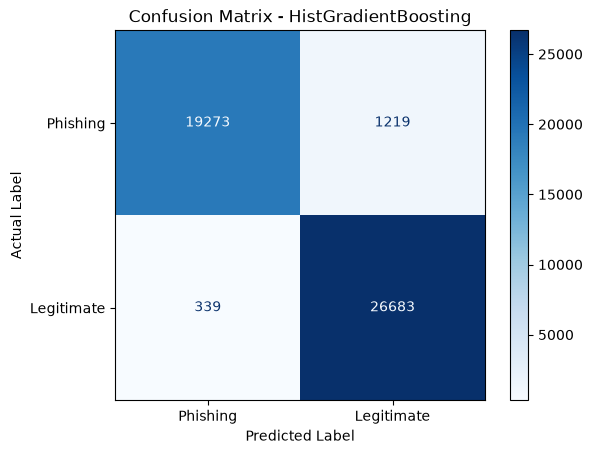

In [187]:
cm_hgb = confusion_matrix(
    y_test_group,
    hgb_pred_final
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hgb,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - HistGradientBoosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Analisis Confusion Matrix - HistGradientBoosting

HistGradientBoosting mampu mengklasifikasikan sebagian besar URL phishing dan legitimate dengan benar. Nilai Phishing Recall yang diperoleh sekitar 94,05%, yang menunjukkan bahwa sebagian besar URL phishing pada data testing berhasil dideteksi.

Phishing Recall HistGradientBoosting sangat dekat dengan Random Forest, tetapi HistGradientBoosting memberikan performa keseluruhan yang sedikit lebih baik pada Accuracy, F1-Score, dan ROC-AUC.

Berdasarkan keseimbangan performa tersebut, HistGradientBoosting dipilih sebagai model final. Meskipun demikian, masih terdapat URL phishing yang salah diklasifikasikan sebagai legitimate sehingga hasil prediksi model tetap perlu diperlakukan sebagai hasil estimasi, bukan jaminan keamanan suatu URL.

In [188]:
comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],

    "Accuracy": [
        accuracy_score(y_test_group, lr_pred_final),
        accuracy_score(y_test_group, final_pred),
        accuracy_score(y_test_group, hgb_pred_final)
    ],

    "F1": [
        f1_score(y_test_group, lr_pred_final),
        f1_score(y_test_group, final_pred),
        f1_score(y_test_group, hgb_pred_final)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test_group, lr_prob_final),
        roc_auc_score(y_test_group, final_prob),
        roc_auc_score(y_test_group, hgb_prob_final)
    ],

    "Phishing Recall": [
        recall_score(y_test_group, lr_pred_final, pos_label=0),
        recall_score(y_test_group, final_pred, pos_label=0),
        recall_score(y_test_group, hgb_pred_final, pos_label=0)
    ]
})

comparison_final.round(4)

,Model,Accuracy,F1,ROC-AUC,Phishing Recall
0,Logistic Regression,0.9521,0.9590,0.9809,0.9077
1,Random Forest,0.9668,0.9712,0.9871,0.9406
2,HistGradientBoosting,0.9672,0.9716,0.9880,0.9405


Berdasarkan evaluasi menggunakan domain-based split, HistGradientBoosting memberikan performa keseluruhan terbaik dengan accuracy 96,72%, F1-Score 97,16%, dan ROC-AUC 98,80%. Ketiga nilai tersebut merupakan yang tertinggi dibandingkan Logistic Regression dan Random Forest.

Random Forest memiliki Phishing Recall sedikit lebih tinggi, yaitu sekitar 94,06%, dibandingkan HistGradientBoosting sekitar 94,05%. Namun, selisih tersebut sangat kecil, sedangkan HistGradientBoosting memberikan hasil yang lebih baik pada Accuracy, F1-Score, dan ROC-AUC.

Logistic Regression memiliki performa paling rendah dari ketiga model, khususnya pada Phishing Recall sebesar 90,77%. Hal ini menunjukkan bahwa model linear tersebut kurang mampu menangkap pola yang lebih kompleks pada fitur URL dibandingkan kedua model ensemble.

Dengan mempertimbangkan performa secara keseluruhan, HistGradientBoosting dipilih sebagai model final karena memberikan keseimbangan terbaik antara kemampuan klasifikasi, F1-Score, ROC-AUC, dan kemampuan mendeteksi URL phishing pada domain yang tidak terdapat dalam data training.

Perbandingan Evaluasi Awal dan Evaluasi Final

Pada eksperimen awal dengan random train-test split, model memperoleh performa di atas 99%. Setelah sistem menggunakan fitur URL yang dapat diekstrak secara langsung dan evaluasi dilakukan menggunakan domain-based split, performa model berada pada kisaran 95–97%.

Penurunan performa ini menunjukkan bahwa pengujian pada domain yang benar-benar berbeda merupakan skenario yang lebih menantang dibandingkan pembagian data secara acak. Meskipun menghasilkan nilai evaluasi yang lebih rendah, pendekatan domain-based memberikan gambaran yang lebih realistis terhadap kemampuan model ketika menerima URL dari domain yang belum pernah dilihat sebelumnya.

Oleh karena itu, hasil domain-based evaluation digunakan sebagai acuan utama dalam menentukan model final.

## **6. Model Saving and Inference Testing**

#### **6.1 Save Final Model**

In [179]:
os.makedirs("./models", exist_ok=True)

joblib.dump(
    final_hgb,
    "./models/phishing_hgb_normalized.pkl"
)

print("Model final berhasil disimpan.")

Model final berhasil disimpan.


In [180]:
joblib.dump(
    hgb_group,
    "./models/phishing_hgb_normalized.pkl"
)

['./models/phishing_hgb_normalized.pkl']

#### **6.2 URL Prediction Function**

In [183]:
def predict_url(url):
    # Extract 15 fitur
    features = extract_features(url)

    # Ubah menjadi DataFrame 1 baris
    features_df = pd.DataFrame([features])

    # Prediksi class
    prediction = model.predict(features_df)[0]

    # Probabilitas
    probabilities = model.predict_proba(features_df)[0]

    # Cari posisi class phishing (label 0)
    phishing_index = list(model.classes_).index(0)

    phishing_probability = probabilities[phishing_index]

    # Ubah hasil menjadi teks
    if prediction == 0:
        result = "Phishing"
    else:
        result = "Legitimate"

    return {
        "url": url,
        "prediction": result,
        "phishing_probability": phishing_probability
    }

In [190]:
result = predict_url("https://www.google.com")

result

{'url': 'https://www.google.com',
 'prediction': 'Legitimate',
 'phishing_probability': np.float64(0.013064466174937062)}

In [191]:
test_urls = [
    "https://www.google.com",
    "https://www.wikipedia.org",
    "http://192.168.1.1/login",
    "http://verify-account-security.example.com/login?id=123"
]

for url in test_urls:
    print(predict_url(url))
    print()

{'url': 'https://www.google.com', 'prediction': 'Legitimate', 'phishing_probability': np.float64(0.013064466174937062)}

{'url': 'https://www.wikipedia.org', 'prediction': 'Legitimate', 'phishing_probability': np.float64(0.020369062002022487)}

{'url': 'http://192.168.1.1/login', 'prediction': 'Phishing', 'phishing_probability': np.float64(0.9999750699428162)}

{'url': 'http://verify-account-security.example.com/login?id=123', 'prediction': 'Phishing', 'phishing_probability': np.float64(0.9999750699428162)}



In [ ]:
#Tes
a = extract_features("https://www.google.com")
b = extract_features("https://www.google.com/")

print(a == b)

True


In [194]:
#Cek url phishing
df_clean[df_clean["label"] == 0]["URL"].sample(
    5,
    random_state=10
).tolist()

['http://www.compress.to',
 'https://fb-restriction-case-a8103.firebaseapp.com/',
 'http://www.st.cloins.com',
 'https://bejadin.sa/outlook/index.html',
 'http://www.iacademygroup.cl']